
# Intro Homework/Tutorial: VQE & Quantum Kernels (Qiskit 2.0+)


This notebook walks you through two core ideas:
1. **Variational Quantum Eigensolver (VQE)** on a small toy Hamiltonian using **Qiskit primitives** and **simulators**
2. **Quantum Kernels** via a simple feature map and **statevector simulation** to compute a kernel matrix.

## 0) Setup & Environment Check

In [1]:
!pip install qiskit qiskit_aer pylatexenc qiskit_ibm_runtime

# You will probably need to restart your session here for pylatexenc.

In [44]:
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Pauli, Operator, Statevector
from qiskit.circuit import ParameterVector

from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit.primitives import StatevectorEstimator
import qiskit_aer
from qiskit_aer import Aer, AerSimulator
import numpy as np
from math import pi
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pylatexenc



---
## Part 1) VQE on a 2‑Qubit Toy Hamiltonian

We will find the approximate ground state energy of a small 2-qubit Hamiltonian using VQE.  
To keep things conceptually clean and runnable without external packages, we’ll use a **toy spin Hamiltonian**:

\[
H = Z \otimes I \;+\; I \otimes Z \;+\; 0.5\,X \otimes X \;+\; 0.5\,Y \otimes Y.
\]

- This Hamiltonian has non-trivial coupling (XX + YY) and local Z terms.
- We'll implement VQE with the **`Estimator` primitive** on an **Aer simulator**.
- We'll compare to the exact ground energy via classical diagonalization (NumPy).


In [3]:
# Build H = ZI + IZ + 0.5*XX + 0.5*YY using SparsePauliOp
paulis = ["ZI", "IZ", "XX", "YY"]
coeffs = [1.0, 1.0, 0.5, 0.5]
H = SparsePauliOp.from_list(list(zip(paulis, coeffs)))
print("Hamiltonian (SparsePauliOp):", H)

# Exact diagonalization (for verification)
# Convert to a 4x4 matrix
H_matrix = H.to_matrix()
evals, evecs = np.linalg.eigh(H_matrix)
E_exact = evals[0]  # ground energy
print("Exact eigenvalues:", evals)
print("Exact ground energy:", E_exact)


Hamiltonian (SparsePauliOp): SparsePauliOp(['ZI', 'IZ', 'XX', 'YY'],
              coeffs=[1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j])
Exact eigenvalues: [-2. -1.  1.  2.]
Exact ground energy: -2.0



### Ansatz

We'll use a simple hardware-efficient style ansatz with two layers:
- Single-qubit rotations: `Ry` then `RZ` on each qubit
- Entangling `CX` between the qubits
- Repeat for a small depth

This gives us enough expressive power to capture the ground state for our toy model without over-complicating the optimization.


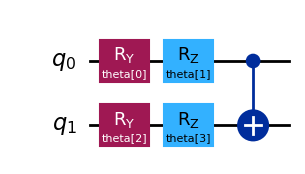

In [4]:


def build_ansatz(depth=3):
    thetas = ParameterVector("theta", length=4*depth)  # for 2 qubits: 2 params per qubit per layer
    qc = QuantumCircuit(2, name="Ansatz")
    idx = 0
    for _ in range(depth):
        # single-qubit rotations
        qc.ry(thetas[idx+0], 0); qc.rz(thetas[idx+1], 0)
        qc.ry(thetas[idx+2], 1); qc.rz(thetas[idx+3], 1)
        idx += 4
        # entangle
        qc.cx(0,1)
    return qc, thetas

ansatz, params = build_ansatz(depth=2)
ansatz.draw(output="mpl")


In [5]:
# Use AerEstimator for fast simulation
backend = Aer.get_backend("aer_simulator")
estimator = Estimator(mode=backend)

def energy_cost(theta_values, H=H, ansatz=ansatz, params=params):
    # Compute <psi(theta)| H |psi(theta)> using Qiskit's Estimator primitive.
    job = estimator.run([(ansatz, H, [theta_values])])
    return job.result()[0].data.evs

# Quick test
test_thetas = np.zeros(len(params))
print("Energy at zero init:", energy_cost(test_thetas))

Energy at zero init: [2.00488281]



### Optimization

We'll default to **COBYLA**.

In [6]:

np.random.seed(42)
theta0 = (2*np.random.rand(len(params)) - 1) * 0.1  # small random init around 0

if minimize is not None:
    res = minimize(lambda th: energy_cost(th), theta0, method="COBYLA", options={"maxiter": 200, "rhobeg": 0.2})
    theta_opt = res.x
    E_vqe = res.fun
    print("Optimizer:", "COBYLA")
else:
    # simple fallback: coordinate-descent-ish
    theta_opt = theta0.copy()
    step = 0.2
    for it in range(120):
        for i in range(len(theta_opt)):
            e0 = energy_cost(theta_opt)
            # try +/- step
            theta_opt[i] += step
            e_plus = energy_cost(theta_opt)
            theta_opt[i] -= 2*step
            e_minus = energy_cost(theta_opt)
            # choose best
            if e_plus < e0 and e_plus <= e_minus:
                theta_opt[i] += step  # keep +step
            elif e_minus < e0 and e_minus < e_plus:
                # keep -step (already subtracted)
                pass
            else:
                # revert
                theta_opt[i] += step
        # small decay
        step *= 0.98
    E_vqe = energy_cost(theta_opt)
    print("Optimizer:", "coordinate descent fallback")

print("VQE energy      :", E_vqe)
print("Exact ground E  :", E_exact)
print("Absolute error  :", abs(E_vqe - E_exact))


Optimizer: COBYLA
VQE energy      : -0.999755859375
Exact ground E  : -2.0
Absolute error  : 1.000244140625



#### Exercises

1. **Depth sweep:** Modify `depth` in `build_ansatz` to 1 and 3. Does VQE converge better/worse? Plot energy vs. iteration if you like.
2. **Warm start:** Try different random initializations. Do you find local minima?
3. **Noise model (optional):** If you're comfortable, add a simple depolarizing noise model to the simulator and see how results degrade.
4. **New Hamiltonian:** Replace `H` with a different small Hamiltonian (e.g., transverse-field Ising on 2 qubits) and repeat.


Part 2) Quantum Kernel (Step 1–4, Simulator‑Only, Qiskit 2.0+ Conventions)
We mirror the modern process while keeping it lightweight.

Flow:

Step 1: Map classical inputs → small dataset, scaling, feature map circuit.
Step 2: Optimize for hardware → transpile(circuit, backend) on a standard simulator to inspect depth/2q gate counts.
Step 3: Execute → compute statevectors with Statevector.from_instruction and form fidelity kernel.
Step 4: Post‑process → kernel matrix visualization and optional SVM with a precomputed kernel.
Step 1: Map classical inputs to a quantum problem

In [36]:
# Tiny 2D dataset: two interleaving arcs
np.random.seed(1)
N = 40
t1 = np.linspace(0, np.pi, N//2)
t2 = np.linspace(0, np.pi, N//2)
X1 = np.c_[np.cos(t1), np.sin(t1)] + 0.15*np.random.randn(N//2, 2)
X2 = np.c_[1 - np.cos(t2), 1 - np.sin(t2) - 0.5] + 0.15*np.random.randn(N//2, 2)
X = np.vstack([X1, X2])
y = np.array([0]*(N//2) + [1]*(N//2))

# Train/Test split
perm = np.random.permutation(N)
train_sz = int(0.7*N)
tr_idx, te_idx = perm[:train_sz], perm[train_sz:]
Xtr, Xte = X[tr_idx], X[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

# Standardize
mu, sigma = Xtr.mean(axis=0), Xtr.std(axis=0) + 1e-9
Xtr_s = (Xtr - mu) / sigma
Xte_s = (Xte - mu) / sigma

# Feature map U(x): angle-encode + entangle + lightweight ZZ interaction
def feature_map_circuit(x):
    x0, x1 = float(x[0]), float(x[1])
    qc = QuantumCircuit(2, name="Φ(x)")
    qc.ry(x0, 0); qc.ry(x1, 1)
    qc.cz(0, 1)
    qc.rzz(0.5*(x0 - x1), 0, 1)
    return qc

Step 2: Optimize problem for quantum hardware execution


In [42]:
# Use an AerSimulator backend and transpile to it (preferred style in Qiskit 2.x)
backend = AerSimulator()  # simulator-only
depths, two_qubit_counts = [], []

for x in Xtr_s[:6]:
    qc = feature_map_circuit(x)
    tqc = transpile(qc, backend=backend, optimization_level=3)
    depths.append(tqc.depth())
    two_qubit_counts.append(sum(1 for g,_,_ in tqc.data if g.name in ("cx","cz")))

print("Avg depth (sample):", float(np.mean(depths)))
print("Avg 2q gates (sample):", float(np.mean(two_qubit_counts)))

/tmp/ipython-input-1944794193.py:9: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  two_qubit_counts.append(sum(1 for g,_,_ in tqc.data if g.name in ("cx","cz")))


Avg depth (sample): 3.0
Avg 2q gates (sample): 1.0


Step 3: Execute using simulators (statevector overlaps)


In [45]:
def statevector_for_x(x):
    qc = feature_map_circuit(x)
    # Direct statevector from instruction (simulator-only, no deprecated execute calls)
    return Statevector.from_instruction(qc)

def fidelity_kernel_entry(x, z):
    psi = statevector_for_x(x)
    phi = statevector_for_x(z)
    # |<psi|phi>|^2
    return float(np.abs(np.vdot(psi.data, phi.data))**2)

def kernel_matrix(XA, XB=None):
    if XB is None: XB = XA
    K = np.zeros((len(XA), len(XB)))
    for i, xa in enumerate(XA):
        for j, xb in enumerate(XB):
            if XB is XA and j < i:
                K[i, j] = K[j, i]
            else:
                K[i, j] = fidelity_kernel_entry(xa, xb)
    return K

Ktr = kernel_matrix(Xtr_s)
Kte = kernel_matrix(Xte_s, Xtr_s)
print("Ktr shape:", Ktr.shape, "| Kte shape:", Kte.shape)

Ktr shape: (28, 28) | Kte shape: (12, 28)


Step 4: Post‑process and return result in desired classical format


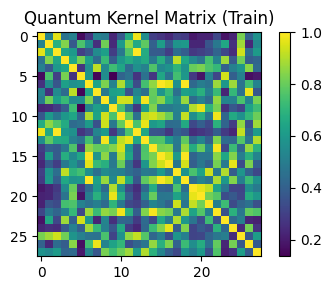

Test accuracy (precomputed quantum kernel): 0.6666666666666666


In [46]:
plt.figure(figsize=(4,3))
plt.imshow(Ktr, interpolation='nearest')
plt.title("Quantum Kernel Matrix (Train)")
plt.colorbar()
plt.tight_layout()
plt.show()

clf = SVC(kernel="precomputed", C=1.0)
clf.fit(Ktr, ytr)
y_pred = clf.predict(Kte)
acc = accuracy_score(yte, y_pred)
print("Test accuracy (precomputed quantum kernel):", acc)


Exercises (lightweight)
Feature map variants: Try rx/rz encoding or remove rzz; rerun Step 2 and compare depths.
Shot-based variant (optional): Swap to a SWAP-test using a Sampler on a shot-based simulator and compare stability vs. runtime.
Classical baseline: Compare with an RBF kernel if scikit-learn is available.


---
## Where to go next

- **Real hardware:** Use `qiskit_ibm_runtime` and primitives (`Estimator`, `Sampler`) against a real backend.
- **Chemistry VQE:** Swap our toy Hamiltonian for a realistic molecular Hamiltonian via `qiskit_nature` (requires that extra package). SQD and SKQD are the newest, best Ising minimizers.  Check them out on IBM Quantum Learning.
- **Advanced kernels:** Look at quantum kernel training/regularization and explicit-feature models in `qiskit-machine-learning`.
- **Error mitigation:** Explore measurement error mitigation and zero-noise extrapolation with shot-based simulators.
